# Callable Expressions in `aes()` --- Beyond String Column Names

In R's ggplot2, `aes()` uses non-standard evaluation (NSE / quosures) to capture
expressions like `aes(y = log(mpg))`. Python has no built-in NSE, so **ggplot2_py**
provides an equivalent mechanism: **callable expressions** (lambdas or functions)
that receive the layer data as a DataFrame.

This tutorial demonstrates how to use callables inside `aes()`, `after_stat()`,
`after_scale()`, and `stage()` --- the three evaluation stages of the ggplot2
pipeline.

In [1]:
%matplotlib agg
import pandas as pd
import numpy as np

np.random.seed(42)
mpg = pd.DataFrame({
    'displ': np.random.uniform(1.5, 7, 100),
    'hwy': np.random.normal(25, 5, 100),
    'cyl': np.random.choice([4, 6, 8], 100),
    'class': np.random.choice(['compact', 'suv', 'midsize'], 100),
})
mpg.head()

,displ,hwy,cyl,class
0,3.559971,25.435235,6,midsize
1,6.728929,23.504963,4,suv
2,5.525967,25.458804,6,compact
3,4.792622,15.062155,4,suv
4,2.358103,23.901641,8,midsize


In [2]:
from ggplot2_py import (
    ggplot, aes, after_stat, after_scale, stage,
    geom_point, geom_histogram, geom_bar,
    labs, theme_minimal,
)

## 1. Basic callable in `aes()`

Instead of pre-computing a column, pass a lambda directly. The lambda receives
the layer DataFrame as its single argument.

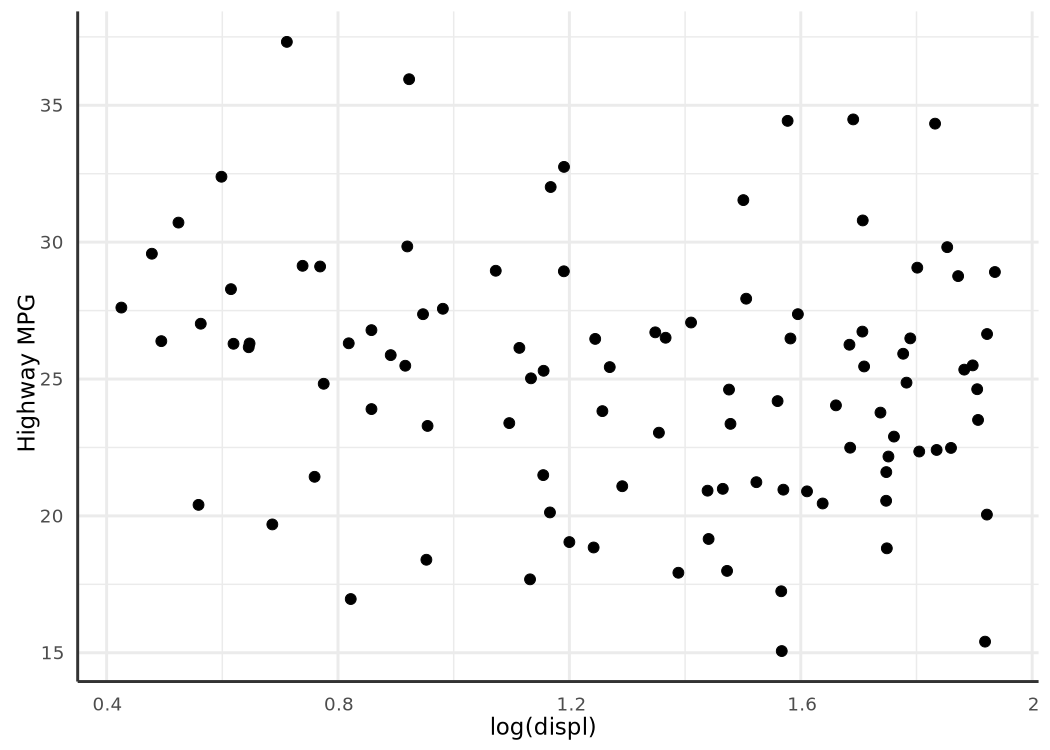

In [3]:
# Log-transform displacement inline --- no need to modify the DataFrame
p = (
    ggplot(mpg, aes(x=lambda d: np.log(d['displ']), y='hwy'))
    + geom_point()
    + labs(x='log(displ)', y='Highway MPG')
    + theme_minimal()
)
p

## 2. `after_stat()` with a callable

`after_stat(fn)` evaluates `fn` on the DataFrame **after** the stat has computed
its summary columns (e.g. `count`, `density`). This lets you normalize or
transform stat output without writing a custom Stat class.

In [ ]:
# Histogram with proportion on the y-axis (normalized counts)
p = (
    ggplot(mpg, aes(x='hwy'))
    + geom_histogram(
        aes(y=after_stat(lambda d: d['count'] / d['count'].sum())),
        bins=15,
    )
    + labs(y='Proportion', title='Highway MPG distribution (proportions)')
    + theme_minimal()
)
p

## 3. `after_scale()` with a callable

`after_scale(fn)` evaluates `fn` on the DataFrame **after** scale mapping has
resolved colour/fill/size/etc. to concrete values. Use this to derive one
aesthetic from another without duplicating the scale.

In [ ]:
# Derive fill from the mapped colour (same hue, applied to fill)
p = (
    ggplot(mpg, aes(x='displ', y='hwy', colour='class'))
    + geom_point(
        aes(fill=after_scale(lambda d: d['colour'])),
        shape=21, size=3, stroke=1,
    )
    + labs(title='Fill derived from colour via after_scale()')
    + theme_minimal()
)
p

## 4. `stage()` --- different mappings at different pipeline stages

The `stage()` helper lets you specify **separate** expressions for:
- `start` --- evaluated on raw data (before stat),
- `after_stat` --- evaluated after stat computation,
- `after_scale` --- evaluated after scale mapping.

This is useful when the grouping variable for stat computation differs from
the final aesthetic.

In [ ]:
# Use 'class' for grouping (start), but after the stat computes counts,
# map the fill based on whether the count exceeds a threshold.
p = (
    ggplot(mpg, aes(x='class'))
    + geom_bar(
        aes(
            fill=stage(
                start='class',
                after_stat=lambda d: np.where(
                    d['count'] > 30, 'high', 'low'
                ),
            )
        )
    )
    + labs(title='stage(): grouping vs conditional fill')
    + theme_minimal()
)
p

## 5. Old way vs new way

Previously you had to pre-compute columns in pandas before plotting.
With callable expressions, the transformation lives inside the plot specification.

In [ ]:
# --- Old way: pre-compute in pandas ---
mpg_old = mpg.copy()
mpg_old['log_displ'] = np.log(mpg_old['displ'])
mpg_old['hwy_per_cyl'] = mpg_old['hwy'] / mpg_old['cyl']

p_old = (
    ggplot(mpg_old, aes(x='log_displ', y='hwy_per_cyl'))
    + geom_point()
    + labs(title='Old way: pre-compute columns')
)

# --- New way: inline callables ---
p_new = (
    ggplot(mpg, aes(
        x=lambda d: np.log(d['displ']),
        y=lambda d: d['hwy'] / d['cyl'],
    ))
    + geom_point()
    + labs(title='New way: inline callables in aes()')
)

# Both produce the same plot
p_new

## 6. How it works: `eval_aes_value()`

Under the hood, the pipeline calls `eval_aes_value(val, data)` for each
aesthetic value. It handles three cases:

| `val` type | Behavior |
|---|---|
| `str` | Looked up as a column name in the DataFrame |
| `callable` | Called with the DataFrame: `val(data)` |
| scalar | Returned unchanged (broadcast by the caller) |

The three evaluation stages in order:

1. **Data stage** --- `aes(x=...)` evaluated on raw layer data.
2. **After-stat stage** --- `after_stat(...)` evaluated after `Stat.compute_*`.
3. **After-scale stage** --- `after_scale(...)` evaluated after scale mapping.

This mirrors R's quosure evaluation but uses Python's first-class functions
instead of non-standard evaluation.

In [ ]:
from ggplot2_py.aes import eval_aes_value

# Demonstrate eval_aes_value directly
sample = mpg.head(5)

# String -> column lookup
print('String lookup:', eval_aes_value('hwy', sample))

# Callable -> evaluated
print('Callable:', eval_aes_value(lambda d: d['hwy'] * 2, sample))

# Scalar -> returned as-is
print('Scalar:', eval_aes_value(3.14, sample))

## Summary

- Use **lambdas/functions** anywhere a string column name is accepted in `aes()`.
- `after_stat(fn)` transforms stat output (e.g. normalize counts).
- `after_scale(fn)` derives aesthetics from scale-mapped values.
- `stage(start=..., after_stat=..., after_scale=...)` provides per-stage control.
- The evaluator `eval_aes_value()` unifies all three value types via a single dispatch point.